In [4]:
#STEP 1
import pandas as pd
import numpy as np
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
# STEP 2: Load the data files

raw_file = "C:/Users/misha/Downloads/COVIDCARE_FORSUBMISSION_MIT_CLEANED_Phase_II_2021-12-03 (1).csv"
kb_file = "C:/Users/misha/Downloads/COVIDCARE_DEMI_knowledgebase_v3 (1).csv"
dict_file = "C:/Users/misha/Downloads/COVIDCARE_survey_dictionary_v2_ForSubmission_MIT_Phase_II_2021-12-26.csv"

# Load the files
df = pd.read_csv(raw_file)
kb = pd.read_csv(kb_file)
dictionary = pd.read_csv(dict_file)

# Check they loaded correctly
print("Raw data shape:", df.shape)
print("Knowledge base shape:", kb.shape)
print("Dictionary shape:", dictionary.shape)

Raw data shape: (822, 472)
Knowledge base shape: (70983, 13)
Dictionary shape: (472, 10)


In [6]:
# STEP 3: Create function to assign tiers to variables

def assign_tier(col_name):
    """Assign tier number based on variable name"""
    c = str(col_name).lower()
    
    # Tier 4: PCR test (comes last)
    if c == "pcr test positive":
        return 4
    
    # Tier 3: At-home test (after symptoms)
    if "pinkline" in c or "blueline" in c or "athome" in c:
        return 3
    
    # Tier 1: Vaccination (before symptoms)
    if "vaccine" in c or "vacc" in c or "flu_shot" in c:
        return 1
    
    # Tier 0: Demographics (fixed at birth)
    if "age" in c or "gender" in c or "race" in c or "ethnicity" in c:
        return 0
    
    # Tier 2: Everything else (symptoms, exposure)
    return 2

# Apply to all columns
tier_df = pd.DataFrame({"variable": df.columns})
tier_df["tier"] = tier_df["variable"].apply(assign_tier)

# Show results
print("Tier counts:")
print(tier_df["tier"].value_counts().sort_index())

# Create a mapping from variable to tier
tier_map = dict(zip(tier_df["variable"], tier_df["tier"]))

Tier counts:
tier
0     24
1     50
2    390
3      7
4      1
Name: count, dtype: int64


In [7]:
# STEP 4: Remove self-comparisons from knowledge base

print("Original knowledge base shape:", kb.shape)

# Exclusion rule: Remove rows where concept_code equals target_concept_code
kb = kb[kb["concept_code"] != kb["target_concept_code"]].copy()

print("After removing self-comparisons:", kb.shape)

Original knowledge base shape: (70983, 13)
After removing self-comparisons: (70983, 13)


In [8]:
# STEP 5: Add tier numbers to the knowledge base

# Add tier columns using the tier_map from Step 4
kb["concept_tier"] = kb["concept_code"].map(tier_map)
kb["target_tier"] = kb["target_concept_code"].map(tier_map)

# Fill any missing values with Tier 2 (symptoms)
kb["concept_tier"] = kb["concept_tier"].fillna(2).astype(int)
kb["target_tier"] = kb["target_tier"].fillna(2).astype(int)

# Show first few rows to verify
print("Knowledge base with tiers added:")
print(kb[["concept_code", "concept_tier", "target_concept_code", "target_tier"]].head(10))

# Show tier distribution
print("\nConcept tiers distribution:")
print(kb["concept_tier"].value_counts().sort_index())

Knowledge base with tiers added:
   concept_code  concept_tier target_concept_code  target_tier
0  30082-Race-1             0        30082-Race-2            0
1  30082-Race-1             0        30082-Race-3            0
2  30082-Race-1             0        30082-Race-4            0
3  30082-Race-1             0        30082-Race-5            0
4  30082-Race-1             0        30082-Race-6            0
5  30082-Race-1             0      30082-Race-998            0
6  30082-Race-1             0      30082-Race-999            0
7  30082-Race-1             0      30086-Gender-1            0
8  30082-Race-1             0      30086-Gender-2            0
9  30082-Race-1             0      30086-Gender-3            0

Concept tiers distribution:
concept_tier
0     5346
1    10526
2    55111
Name: count, dtype: int64


In [9]:
# STEP 6: Apply temporal rules to determine which variable comes first

def apply_temporal_rules(row):
    """
    Apply rules to determine n_code_before_target and n_target_before_code
    """
    n11 = row["n_code_target"]  # both present
    n10 = row["n_code_no_target"]  # only A present
    n01 = row["n_target_no_code"]  # only B present
    
    ct = row["concept_tier"]  # tier of A
    tt = row["target_tier"]   # tier of B
    
    # RULE 1: Zero co-occurrence (never appear together)
    if n11 == 0:
        row["n_code_before_target_final"] = n10
        row["n_target_before_code_final"] = n01
        return row
    
    # RULE 2: Different tiers - lower tier always comes first
    if ct < tt:
        row["n_code_before_target_final"] = n11
        row["n_target_before_code_final"] = 0
        return row
    
    if ct > tt:
        row["n_code_before_target_final"] = 0
        row["n_target_before_code_final"] = n11
        return row
    
    # RULE 3: Same tier - symmetric (both directions equal)
    row["n_code_before_target_final"] = n11
    row["n_target_before_code_final"] = n11
    return row

# Apply rules to knowledge base
kb = kb.apply(apply_temporal_rules, axis=1)

print("Temporal rules applied!")
print("\nSample results:")
print(kb[["concept_code", "target_concept_code", "concept_tier", "target_tier", 
          "n_code_target", "n_code_before_target_final", "n_target_before_code_final"]].head(10))

Temporal rules applied!

Sample results:
   concept_code target_concept_code  concept_tier  target_tier  n_code_target  \
0  30082-Race-1        30082-Race-2             0            0             20   
1  30082-Race-1        30082-Race-3             0            0              3   
2  30082-Race-1        30082-Race-4             0            0              7   
3  30082-Race-1        30082-Race-5             0            0              0   
4  30082-Race-1        30082-Race-6             0            0              2   
5  30082-Race-1      30082-Race-998             0            0              0   
6  30082-Race-1      30082-Race-999             0            0              0   
7  30082-Race-1      30086-Gender-1             0            0            132   
8  30082-Race-1      30086-Gender-2             0            0            272   
9  30082-Race-1      30086-Gender-3             0            0              4   

   n_code_before_target_final  n_target_before_code_final  
0      

In [10]:
# STEP 7: Create pairwise associations table using correct column names

# Select the right columns
pairwise = kb[["concept_code", "target_concept_code", 
               "concept_tier", "target_tier",
               "n_code_target", 
               "n_code_before_target_final", 
               "n_target_before_code_final"]].copy()

# Rename columns for clarity
pairwise.columns = ["var_a", "var_b", "tier_a", "tier_b", 
                    "both_present", "a_before_b", "b_before_a"]

# Sort by strongest association (most co-occurrences)
pairwise_sorted = pairwise.sort_values("both_present", ascending=False)

print("PAIRWISE ASSOCIATIONS TABLE")
print("=" * 85)
print(f"{'Var A':<30} {'Var B':<30} {'Both':<8} {'A→B':<8} {'B→A':<8}")
print("-" * 85)

# Show top 15 strongest pairs
for i in range(min(15, len(pairwise_sorted))):
    row = pairwise_sorted.iloc[i]
    var_a_short = row['var_a'][:28] if len(row['var_a']) > 28 else row['var_a']
    var_b_short = row['var_b'][:28] if len(row['var_b']) > 28 else row['var_b']
    print(f"{var_a_short:<30} {var_b_short:<30} {row['both_present']:<8} {row['a_before_b']:<8} {row['b_before_a']:<8}")

print("-" * 85)
print(f"\nTotal pairs: {len(pairwise)}")

PAIRWISE ASSOCIATIONS TABLE
Var A                          Var B                          Both     A→B      B→A     
-------------------------------------------------------------------------------------
30160-Symptom_Inflamm-1        31386-covid_results-2          584      584      584     
31405-skipped_why-4            31386-covid_results-2          582      582      582     
bin_32136-vaccine_didyou       bin_30171-COVID_vaccine        577      577      577     
bin_30171-COVID_vaccine        bin_32136-vaccine_didyou       577      577      577     
31344-devices_own-3            31386-covid_results-2          576      576      576     
31405-skipped_why-4            31344-devices_own-3            562      562      562     
31405-skipped_why-4            30160-Symptom_Inflamm-1        562      562      562     
30160-Symptom_Inflamm-1        31405-skipped_why-4            562      562      562     
31344-devices_own-3            31405-skipped_why-4            562      562      562  

In [11]:
# STEP 8: Add 2x2 table columns to kb

# These columns are needed for association measures
kb["n11"] = kb["n_code_target"]           # Both present
kb["n10"] = kb["n_code_no_target"]        # Only A present  
kb["n01"] = kb["n_target_no_code"]        # Only B present
kb["n00"] = kb["n_no_code_no_target"]     # Neither present

# Total patients for this pair
kb["N"] = kb["n11"] + kb["n10"] + kb["n01"] + kb["n00"]

print("2x2 table columns added!")
print("\nFirst 5 rows:")
print(kb[["concept_code", "target_concept_code", "n11", "n10", "n01", "n00", "N"]].head(5))

2x2 table columns added!

First 5 rows:
   concept_code target_concept_code  n11  n10  n01  n00    N
0  30082-Race-1        30082-Race-2   20  385  333   45  783
1  30082-Race-1        30082-Race-3    3  402   27  351  783
2  30082-Race-1        30082-Race-4    7  398    6  372  783
3  30082-Race-1        30082-Race-5    0  405    2  376  783
4  30082-Race-1        30082-Race-6    2  403   11  367  783


In [12]:
# STEP 9: Calculate association measures (odds ratio, phi, probabilities)

# Odds ratio with 0.5 correction (avoids division by zero)
kb["odds_ratio"] = ((kb["n11"] + 0.5) * (kb["n00"] + 0.5)) / ((kb["n10"] + 0.5) * (kb["n01"] + 0.5))
kb["log_odds_ratio"] = np.log(kb["odds_ratio"])

# Phi coefficient (correlation between two binary variables)
num = kb["n11"] * kb["n00"] - kb["n10"] * kb["n01"]
den = np.sqrt(
    (kb["n11"] + kb["n10"]) *
    (kb["n01"] + kb["n00"]) *
    (kb["n11"] + kb["n01"]) *
    (kb["n10"] + kb["n00"])
)
kb["phi"] = np.where(den == 0, np.nan, num / den)

# Support (how common is this pair)
kb["support_both"] = kb["n11"] / kb["N"]

# Conditional probabilities
# P(target | concept) = probability of B given A
kb["p_target_given_code"] = np.where(
    (kb["n11"] + kb["n10"]) == 0, 
    np.nan, 
    kb["n11"] / (kb["n11"] + kb["n10"])
)

# P(target | no concept) = probability of B given not A
kb["p_target_given_no_code"] = np.where(
    (kb["n01"] + kb["n00"]) == 0, 
    np.nan, 
    kb["n01"] / (kb["n01"] + kb["n00"])
)

print("Association measures calculated!")
print("\nSample results:")
print(kb[["concept_code", "target_concept_code", "odds_ratio", "phi", "p_target_given_code"]].head(10))

Association measures calculated!

Sample results:
   concept_code target_concept_code  odds_ratio       phi  p_target_given_code
0  30082-Race-1        30082-Race-2    0.007255 -0.835123             0.049383
1  30082-Race-1        30082-Race-3    0.111146 -0.166663             0.007407
2  30082-Race-1        30082-Race-4    1.078564  0.005518             0.017284
3  30082-Race-1        30082-Race-5    0.185697 -0.052381             0.000000
4  30082-Race-1        30082-Race-6    0.197996 -0.094492             0.004938
5  30082-Race-1      30082-Race-998    0.102617 -0.074172             0.000000
6  30082-Race-1      30082-Race-999    0.132288 -0.064194             0.000000
7  30082-Race-1      30086-Gender-1    1.177174  0.037761             0.325926
8  30082-Race-1      30086-Gender-2    0.861669 -0.034593             0.671605
9  30082-Race-1      30086-Gender-3    0.932752 -0.003506             0.009877


In [13]:
# STEP 10: Save to CSV file

pairwise_assoc = kb[[
    "concept_code", "target_concept_code",
    "concept_tier", "target_tier",
    "n11", "n10", "n01", "n00",
    "support_both", "odds_ratio", "log_odds_ratio", "phi",
    "p_target_given_code", "p_target_given_no_code",
    "n_code_before_target_final", "n_target_before_code_final"
]].copy()

pairwise_assoc.to_csv("pairwise_associations.csv", index=False)
print("\n✅ Saved: pairwise_associations.csv")
print(f"   Rows: {len(pairwise_assoc)}")


✅ Saved: pairwise_associations.csv
   Rows: 70983


In [14]:
# STEP 11: Save frequencies of each variable pair

pair_freq = kb[["concept_code", "target_concept_code", "n_code_target"]].copy()
pair_freq = pair_freq.sort_values("n_code_target", ascending=False)
pair_freq.to_csv("pairwise_frequencies.csv", index=False)

print("✅ Saved: pairwise_frequencies.csv")
print(f"   Total pairs: {len(pair_freq)}")
print(f"   Highest frequency: {pair_freq['n_code_target'].max()}")
print(f"   Average frequency: {pair_freq['n_code_target'].mean():.1f}")

print("\nTOP 10 MOST FREQUENT PAIRS:")
print("=" * 70)
print(f"{'Concept':<35} {'Target':<35} {'Count':<10}")
print("-" * 70)

for i in range(min(10, len(pair_freq))):
    row = pair_freq.iloc[i]
    print(f"{row['concept_code'][:34]:<35} {row['target_concept_code'][:34]:<35} {row['n_code_target']:<10}")

✅ Saved: pairwise_frequencies.csv
   Total pairs: 70983
   Highest frequency: 584
   Average frequency: 7.4

TOP 10 MOST FREQUENT PAIRS:
Concept                             Target                              Count     
----------------------------------------------------------------------
30160-Symptom_Inflamm-1             31386-covid_results-2               584       
31405-skipped_why-4                 31386-covid_results-2               582       
bin_32136-vaccine_didyou            bin_30171-COVID_vaccine             577       
bin_30171-COVID_vaccine             bin_32136-vaccine_didyou            577       
31344-devices_own-3                 31386-covid_results-2               576       
31405-skipped_why-4                 31344-devices_own-3                 562       
31405-skipped_why-4                 30160-Symptom_Inflamm-1             562       
30160-Symptom_Inflamm-1             31405-skipped_why-4                 562       
31344-devices_own-3                 31405-ski

In [15]:
# STEP 12: Prepare raw modeling data 

TARGET = "PCR Test Positive"

def is_date_or_id_or_admin(col):
    c = str(col).lower()
    if c == TARGET.lower():
        return False
    return (
        "date" in c
        or "submission" in c
        or "confirmation" in c
        or "internal id" in c
        or "cohort" in c
        or "_deid" in c
        or "name" in c
        or "phone" in c
        or "email" in c
    )

# Filter columns
usable_cols = [c for c in df.columns if not is_date_or_id_or_admin(c)]
model_df = df[usable_cols].copy()

# Make sure target is in the dataframe
if TARGET not in model_df.columns:
    model_df[TARGET] = df[TARGET]

print(f"Original columns: {len(df.columns)}")
print(f"Usable columns: {len(usable_cols)}")
print(f"Removed: {len(df.columns) - len(usable_cols)} columns")
print(f"\nSample of usable columns:")
print(usable_cols[:15])

Original columns: 472
Usable columns: 445
Removed: 27 columns

Sample of usable columns:
['PCR Test Positive', '29789-consent_18yrs', '29790-consent_applies', '29791-consent_english', '29792-consent_covid+', '29793-consent_location', '29794-consent_noeligble', '34683-consent_invited', '34684-consent_travel', '29826-storage_permission', '29829-consent', '32730-howreceive', '29858-Shipping_placement', '32150-preferred_time', '29871-KitReceived_response']


In [16]:
# STEP 13: Convert all columns to numeric for modeling

# Convert object (string) columns to category codes
for col in model_df.columns:
    if model_df[col].dtype == "object":
        model_df[col] = model_df[col].astype("category").cat.codes.replace(-1, np.nan)

# Convert boolean columns to integers
for col in model_df.columns:
    if str(model_df[col].dtype) == "bool":
        model_df[col] = model_df[col].astype(int)

# Ensure target is binary numeric
model_df[TARGET] = pd.to_numeric(model_df[TARGET], errors="coerce")
model_df = model_df.dropna(subset=[TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(int)

print(f"Model dataframe shape after conversion: {model_df.shape}")
print(f"Target - Positive: {(model_df[TARGET] == 1).sum()}, Negative: {(model_df[TARGET] == 0).sum()}")
print(f"\nData types after conversion:")
print(model_df.dtypes.value_counts())

Model dataframe shape after conversion: (559, 445)
Target - Positive: 58, Negative: 501

Data types after conversion:
float64    434
int64       11
Name: count, dtype: int64


In [17]:
# STEP 14: Keep only variables that come BEFORE PCR (tier < 4)

# Use the assign_tier function from Step 4
predictor_cols = [c for c in model_df.columns if c != TARGET and assign_tier(c) < 4]
X_base = model_df[predictor_cols].copy()
y = model_df[TARGET].copy()

print(f"Predictor columns: {len(predictor_cols)}")
print(f"X_base shape: {X_base.shape}")
print(f"y shape: {y.shape}")
print(f"Positive cases: {y.sum()}")
print(f"\nSample predictors: {predictor_cols[:10]}")

Predictor columns: 444
X_base shape: (559, 444)
y shape: (559,)
Positive cases: 58

Sample predictors: ['29789-consent_18yrs', '29790-consent_applies', '29791-consent_english', '29792-consent_covid+', '29793-consent_location', '29794-consent_noeligble', '34683-consent_invited', '34684-consent_travel', '29826-storage_permission', '29829-consent']


In [18]:
# STEP 15: Create pairwise and triple interactions

import itertools

# Get symptom and at-home test variables (Tier 2 and Tier 3)
symptom_home_vars = [c for c in predictor_cols if assign_tier(c) in [2, 3]]

# Keep a manageable number to avoid explosion
pair_base = symptom_home_vars[:20]    # First 20 for pairs
triple_base = symptom_home_vars[:8]   # First 8 for triples

print(f"Using {len(pair_base)} variables for pairwise interactions")
print(f"Using {len(triple_base)} variables for triple interactions")

# Start with original features
X = X_base.copy()

# Add pairwise interactions
pair_count = 0
for a, b in itertools.combinations(pair_base, 2):
    X[f"{a}__X__{b}"] = X[a].fillna(0) * X[b].fillna(0)
    pair_count += 1

print(f"Added {pair_count} pairwise interactions")

# Add triple interactions
triple_count = 0
for a, b, c in itertools.combinations(triple_base, 3):
    X[f"{a}__X__{b}__X__{c}"] = X[a].fillna(0) * X[b].fillna(0) * X[c].fillna(0)
    triple_count += 1

print(f"Added {triple_count} triple interactions")
print(f"Final feature matrix shape: {X.shape}")

Using 20 variables for pairwise interactions
Using 8 variables for triple interactions
Added 190 pairwise interactions
Added 56 triple interactions
Final feature matrix shape: (559, 690)


In [19]:
# STEP 16: Split data into train and test sets

from sklearn.model_selection import train_test_split

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} patients, {X_test.shape[1]} features")
print(f"Training positive cases: {y_train.sum()}")
print(f"Test positive cases: {y_test.sum()}")

Training set: 419 patients, 690 features
Test set: 140 patients, 690 features
Training positive cases: 43
Test positive cases: 15


In [20]:
# STEP 17: Define models to compare

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer

# Prepare data (handle missing values, scale)
prep_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler())
    ]), X.columns.tolist())
])

# Model 1: Simple Logistic Regression
log_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

# Model 2: LASSO with cross-validation
lasso_model = Pipeline([
    ("prep", prep_scaled),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        class_weight="balanced"
    ))
])

# Model 3: Gradient Boosting
boost_model = Pipeline([
    ("prep", prep_scaled),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

models = {
    "Logistic": log_model,
    "LASSO": lasso_model,
    "GradientBoost": boost_model
}

print("Models defined:")
for name in models:
    print(f"  - {name}")

Models defined:
  - Logistic
  - LASSO
  - GradientBoost


In [21]:
# STEP 18: Model evaluation and comparison

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import log_loss

def mcfadden_r2(y_true, prob):
    """Calculate McFadden Pseudo R-Square"""
    prob = np.clip(prob, 1e-8, 1 - 1e-8)
    ll_model = -log_loss(y_true, prob, normalize=False)
    p_null = np.repeat(np.mean(y_true), len(y_true))
    p_null = np.clip(p_null, 1e-8, 1 - 1e-8)
    ll_null = -log_loss(y_true, p_null, normalize=False)
    return 1 - (ll_model / ll_null)

# Train and evaluate each model
results = []
fitted_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    
    # Predict on test set
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    
    # Calculate metrics
    auc = roc_auc_score(y_test, prob)
    acc = accuracy_score(y_test, pred)
    mcfadden = mcfadden_r2(y_test, prob)
    
    results.append({
        "Model": name,
        "AUC": auc,
        "Accuracy": acc,
        "McFadden_R2": mcfadden,
        "Percent_Variation_Explained": mcfadden * 100
    })
    
    print(f"  AUC: {auc:.4f}")
    print(f"  Accuracy: {acc:.2%}")
    print(f"  McFadden R2: {mcfadden:.4f}")

# Create results dataframe and sort by AUC
results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

print("\n" + "=" * 60)
print("MODEL RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv("model_results.csv", index=False)
print("\n✅ Saved: model_results.csv")


Training Logistic...
  AUC: 0.9589
  Accuracy: 94.29%
  McFadden R2: 0.2445

Training LASSO...
  AUC: 0.9200
  Accuracy: 94.29%
  McFadden R2: 0.2146

Training GradientBoost...
  AUC: 0.9245
  Accuracy: 95.00%
  McFadden R2: 0.4322

MODEL RESULTS
        Model      AUC  Accuracy  McFadden_R2  Percent_Variation_Explained
     Logistic 0.958933  0.942857     0.244485                    24.448475
GradientBoost 0.924533  0.950000     0.432172                    43.217215
        LASSO 0.920000  0.942857     0.214593                    21.459341

✅ Saved: model_results.csv


In [22]:
# STEP 19: Get direct predictors from LASSO 

# Get fitted LASSO model
lasso_fitted = fitted_models["LASSO"].named_steps["model"]

# Get coefficients
lasso_coef = lasso_fitted.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "variable": X.columns,
    "coefficient": lasso_coef
})

# Keep only non-zero
direct_predictors = coef_df[coef_df["coefficient"] != 0].copy()
direct_predictors["abs_coef"] = direct_predictors["coefficient"].abs()
direct_predictors = direct_predictors.sort_values("abs_coef", ascending=False)

print("\nDIRECT PREDICTORS OF PCR TEST RESULTS")
print(direct_predictors.head(30))


DIRECT PREDICTORS OF PCR TEST RESULTS
                                           variable  coefficient  abs_coef
202                           30158-Symtpom_Neuro-7     0.911709  0.911709
293                          30766-pinkblue_confirm     0.471179  0.471179
420                           31386-covid_results-1     0.465763  0.465763
124                      30141-covid_tst_symptoms-3     0.278520  0.278520
518     29793-consent_location__X__32730-howreceive     0.263850  0.263850
10                                 32730-howreceive     0.263850  0.263850
568              29829-consent__X__32730-howreceive     0.263850  0.263850
487      29791-consent_english__X__32730-howreceive     0.263850  0.263850
452        29789-consent_18yrs__X__32730-howreceive     0.263850  0.263850
72                         30103-conditionsrisks-20    -0.262434  0.262434
81                              32137-vaccine_avail     0.255667  0.255667
580       32730-howreceive__X__32150-preferred_time     0.245

In [23]:
# STEP 20: Regress each direct predictor on preceding variables 
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

def fit_parent_model(response_var):
    response_tier = assign_tier(response_var)

    parents = [c for c in model_df.columns 
               if c != response_var and assign_tier(c) < response_tier]

    if len(parents) == 0:
        return None, None

    temp_df = model_df[parents + [response_var]].copy()
    temp_df[response_var] = pd.to_numeric(temp_df[response_var], errors="coerce")
    temp_df = temp_df.dropna(subset=[response_var]).copy()

    if temp_df.shape[0] < 10:
        return None, None

    temp_df[response_var] = temp_df[response_var].astype(int)

    unique_vals = sorted(temp_df[response_var].dropna().unique())
    if not set(unique_vals).issubset({0, 1}):
        return None, None

    Xp = temp_df[parents].copy()
    yp = temp_df[response_var].copy()

    Xp_train, Xp_test, yp_train, yp_test = train_test_split(
        Xp, yp, test_size=0.25, random_state=42, stratify=yp
    )

    if yp_train.nunique() < 2 or yp_test.nunique() < 2:
        return None, None

    imputer = SimpleImputer(strategy="most_frequent")
    Xp_train = pd.DataFrame(imputer.fit_transform(Xp_train), columns=Xp.columns, index=Xp_train.index)
    Xp_test = pd.DataFrame(imputer.transform(Xp_test), columns=Xp.columns, index=Xp_test.index)

    model = LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        cv=5,
        max_iter=5000,
        n_jobs=-1
    )

    model.fit(Xp_train, yp_train)
    prob = model.predict_proba(Xp_test)[:, 1]

    ll_model = -log_loss(yp_test, prob, normalize=False)
    p_null = np.repeat(np.mean(yp_test), len(yp_test))
    ll_null = -log_loss(yp_test, p_null, normalize=False)
    r2 = 1 - (ll_model / ll_null)

    coef_df = pd.DataFrame({
        "parent": parents,
        "coef": model.coef_[0]
    })

    coef_df = coef_df[coef_df["coef"] != 0].copy()
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return coef_df, r2

# Run for top direct predictors
markov_results = {}

for var in direct_predictors["variable"].head(15):
    if var in model_df.columns:
        coef, r2 = fit_parent_model(var)

        if coef is not None and not coef.empty:
            markov_results[var] = {"coef": coef, "r2": r2}

            print("\nResponse:", var)
            print("McFadden R2:", r2)
            print(coef.head(10))


Response: 30103-conditionsrisks-20
McFadden R2: -0.12444912584375523
                      parent      coef  abs_coef
3               30082-Race-2 -0.092237  0.092237
49   36096-Post_covidvaccine -0.080642  0.080642
2               30082-Race-1  0.062831  0.062831
12            30086-Gender-1 -0.032032  0.032032
50  36097-Post_vaccinelikely  0.026770  0.026770
4               30082-Race-3  0.024589  0.024589
13            30086-Gender-2  0.023661  0.023661
10        30680-race_specify  0.017792  0.017792
47  30172-COVID_vaccine_type -0.014432  0.014432
24       32137-vaccine_avail  0.014117  0.014117

Response: 31344-devices_own-2
McFadden R2: -0.0022956964571663185
                 parent      coef  abs_coef
11      30085-Ethnicity -0.000435  0.000435
46  30171-COVID_vaccine -0.000300  0.000300
45       30170-Flu_shot -0.000077  0.000077


In [24]:
# STEP 21: Significant predictors (Markov blanket)

print("\n" + "=" * 70)
print("SIGNIFICANT PREDICTORS (MARKOV BLANKET)")
print("=" * 70)

for response_var, result in markov_results.items():
    print("\nResponse Variable:", response_var)
    print("Significant Parent Predictors:")
    print(result["coef"][["parent", "coef"]].head(10))


SIGNIFICANT PREDICTORS (MARKOV BLANKET)

Response Variable: 30103-conditionsrisks-20
Significant Parent Predictors:
                      parent      coef
3               30082-Race-2 -0.092237
49   36096-Post_covidvaccine -0.080642
2               30082-Race-1  0.062831
12            30086-Gender-1 -0.032032
50  36097-Post_vaccinelikely  0.026770
4               30082-Race-3  0.024589
13            30086-Gender-2  0.023661
10        30680-race_specify  0.017792
47  30172-COVID_vaccine_type -0.014432
24       32137-vaccine_avail  0.014117

Response Variable: 31344-devices_own-2
Significant Parent Predictors:
                 parent      coef
11      30085-Ethnicity -0.000435
46  30171-COVID_vaccine -0.000300
45       30170-Flu_shot -0.000077


In [25]:
# STEP 22: Percent variation explained 

print("\n" + "=" * 70)
print("PERCENT VARIATION EXPLAINED")
print("=" * 70)

for response_var, result in markov_results.items():
    r2 = result["r2"]
    print("\nResponse:", response_var)
    print("McFadden R2:", r2)
    print("Percent Variation Explained:", r2 * 100)


PERCENT VARIATION EXPLAINED

Response: 30103-conditionsrisks-20
McFadden R2: -0.12444912584375523
Percent Variation Explained: -12.444912584375523

Response: 31344-devices_own-2
McFadden R2: -0.0022956964571663185
Percent Variation Explained: -0.22956964571663185


In [27]:
import networkx as nx

# Create graph
G = nx.DiGraph()

# Add edges from Markov blanket (parent → child)
for child, result in markov_results.items():
    if result is not None and "coef" in result:
        for _, row in result["coef"].iterrows():
            G.add_edge(row["parent"], child)

# Add edges from direct predictors to PCR
TARGET = "PCR Test Positive"
for var in direct_predictors["variable"].head(15):
    if var in model_df.columns:
        G.add_edge(var, TARGET)

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph built: 61 nodes, 64 edges


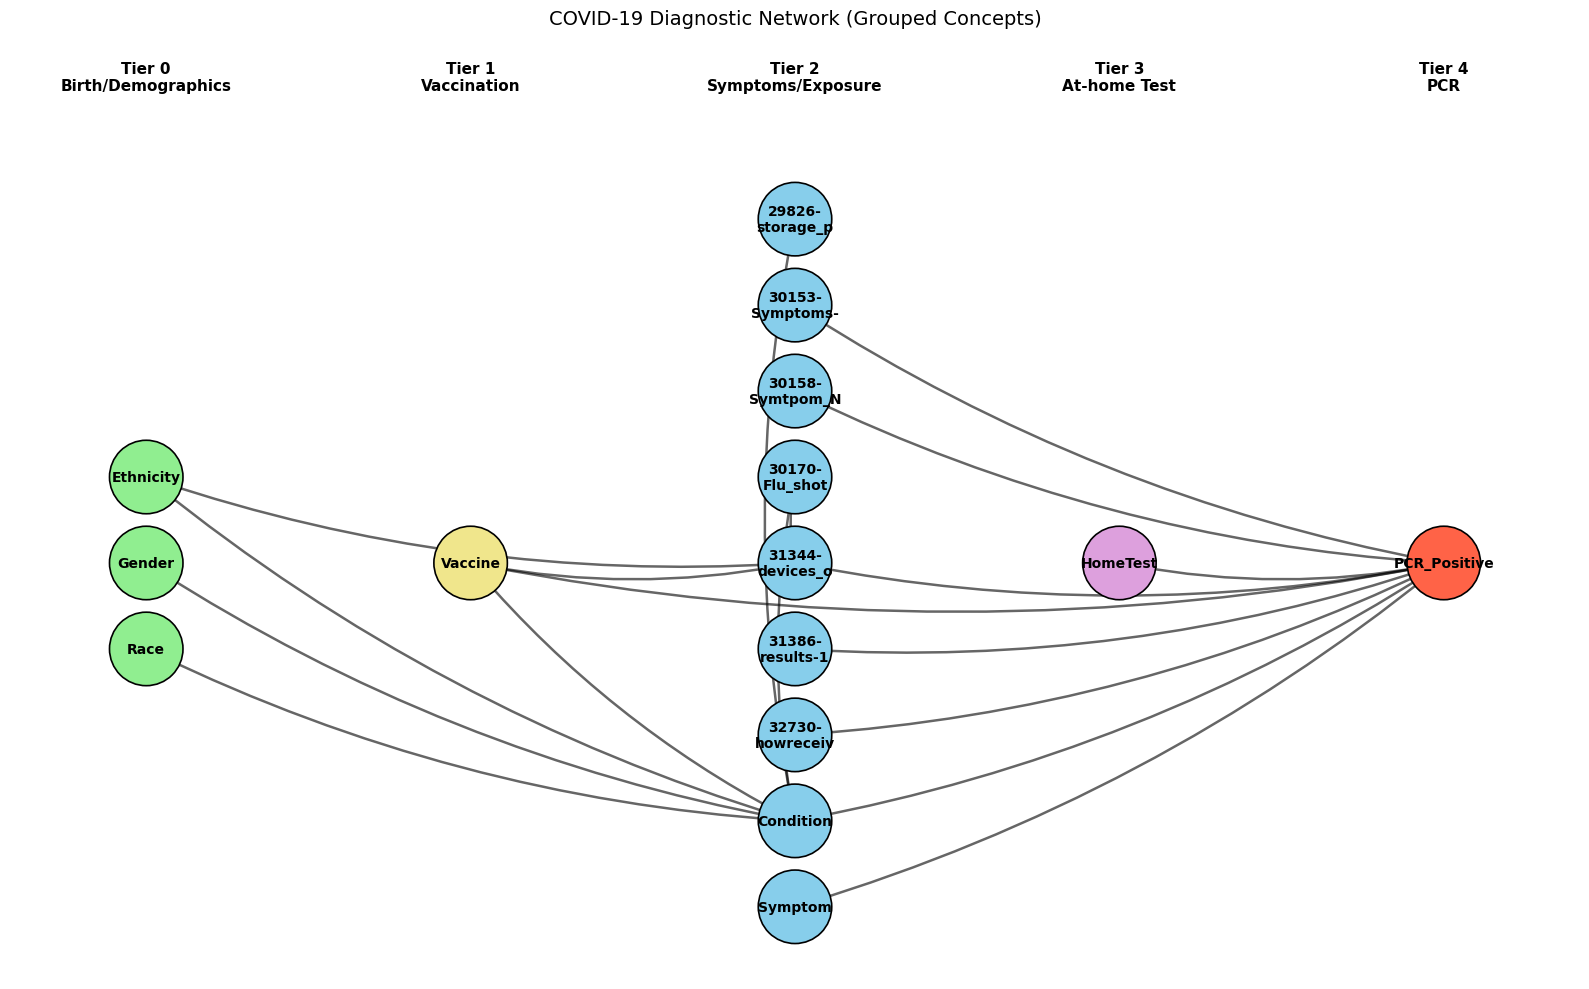

✅ Clean network saved as covid_network_clean.png


In [28]:
# STEP 23: FINAL CLEAN NETWORK VISUALIZATION 
import matplotlib.pyplot as plt
import networkx as nx
import textwrap

# ---------------------------------------------------------
# 1. GROUP VARIABLES BY CONCEPT
# ---------------------------------------------------------
def group_concept(name):
    name = str(name)
    if "vaccine" in name.lower() or "vacc" in name.lower():
        return "Vaccine"
    if "race" in name.lower():
        return "Race"
    if "gender" in name.lower():
        return "Gender"
    if "ethnicity" in name.lower():
        return "Ethnicity"
    if "covid_tst_symptoms" in name:
        return "Symptom"
    if "conditionsrisks" in name:
        return "Condition"
    if "consent" in name.lower():
        return "Consent"
    if "pinkblue" in name or "blue_nopink" in name:
        return "HomeTest"
    if name == TARGET:
        return "PCR_Positive"
    short = name.replace("30141-", "").replace("covid_", "").replace("tst_", "")
    return "\n".join(textwrap.wrap(short[:15], width=10))

G_clean = nx.DiGraph()
for parent, child in G.edges():
    p_group = group_concept(parent)
    c_group = group_concept(child)
    if p_group != c_group:
        G_clean.add_edge(p_group, c_group)

# ---------------------------------------------------------
# 2. TIER ASSIGNMENT FOR GROUPED NODES
# ---------------------------------------------------------
def assign_tier_group(node):
    if node in ["Age", "Gender", "Race", "Ethnicity", "Birth"]:
        return 0
    if node in ["Vaccine", "Flu_shot", "Vaccine_attitude"]:
        return 1
    if node in ["Symptom", "Condition", "Exposure"]:
        return 2
    if node in ["HomeTest", "Rapid_test"]:
        return 3
    if node == "PCR_Positive":
        return 4
    return 2

# ---------------------------------------------------------
# 3. TIERED LAYOUT
# ---------------------------------------------------------
def tiered_layout(graph, x_gap=4, y_gap=1.5):
    pos = {}
    tier_nodes = {}
    for node in graph.nodes():
        t = assign_tier_group(node)
        tier_nodes.setdefault(t, []).append(node)
    for tier, nodes in tier_nodes.items():
        nodes = sorted(nodes)
        n = len(nodes)
        center = (n - 1) / 2
        for i, node in enumerate(nodes):
            pos[node] = (tier * x_gap, (center - i) * y_gap)
    return pos

pos = tiered_layout(G_clean, x_gap=4, y_gap=1.5)

# ---------------------------------------------------------
# 4. NODE COLORS BY TIER
# ---------------------------------------------------------
node_colors = []
for node in G_clean.nodes():
    tier = assign_tier_group(node)
    if node == "PCR_Positive":
        node_colors.append("tomato")
    elif tier == 0:
        node_colors.append("lightgreen")
    elif tier == 1:
        node_colors.append("khaki")
    elif tier == 2:
        node_colors.append("skyblue")
    elif tier == 3:
        node_colors.append("plum")
    else:
        node_colors.append("lightgray")

# ---------------------------------------------------------
# 5. DRAW NETWORK
# ---------------------------------------------------------
plt.figure(figsize=(16, 10))

nx.draw_networkx_edges(
    G_clean, pos,
    arrows=True, alpha=0.6, width=1.8,
    arrowstyle='-|>', arrowsize=14,
    connectionstyle="arc3,rad=0.1"
)

nx.draw_networkx_nodes(
    G_clean, pos,
    node_size=2800, node_color=node_colors,
    edgecolors="black", linewidths=1.2
)

nx.draw_networkx_labels(
    G_clean, pos,
    font_size=10, font_weight="bold"
)

# ---------------------------------------------------------
# 6. ADD TIER TITLES (NO OVERLAP)
# ---------------------------------------------------------
tier_titles = {
    0: "Tier 0\nBirth/Demographics",
    1: "Tier 1\nVaccination",
    2: "Tier 2\nSymptoms/Exposure",
    3: "Tier 3\nAt-home Test",
    4: "Tier 4\nPCR"
}

ax = plt.gca()
y_min, y_max = ax.get_ylim()
new_y_max = y_max + 2.0   # add extra space at top
ax.set_ylim(y_min, new_y_max)

title_y = new_y_max - 0.5

for tier, title in tier_titles.items():
    plt.text(tier * 4, title_y, title,
             ha="center", va="top", fontsize=11, fontweight="bold")

plt.title("COVID-19 Diagnostic Network (Grouped Concepts)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("covid_network_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Clean network saved as covid_network_clean.png")

In [30]:
# STEP: Define create_cpt function

import itertools
from sklearn.linear_model import LogisticRegression

def create_cpt(response_var, max_parents=5):
    """Create conditional probability table for a response variable"""
    result = markov_results.get(response_var, None)
    if result is None:
        return pd.DataFrame()
    
    # Get top parents
    parents = result["coef"]["parent"].tolist()[:max_parents]
    
    if len(parents) == 0:
        return pd.DataFrame()
    
    # Create all combinations of parent values (0/1)
    combos = list(itertools.product([0, 1], repeat=len(parents)))
    cpt = pd.DataFrame(combos, columns=parents)
    
    # Get data
    Xp = model_df[parents].fillna(0)
    yp = model_df[response_var].fillna(0).astype(int)
    
    # Train logistic regression
    model = LogisticRegression(max_iter=5000)
    model.fit(Xp, yp)
    
    # Predict probability for each combination
    cpt[f"P({response_var}=1)"] = model.predict_proba(cpt)[:, 1]
    cpt[f"P({response_var}=0)"] = 1 - cpt[f"P({response_var}=1)"]
    
    return cpt

In [31]:
# STEP 24: Check which variables have parents
print("Variables with parents in markov_results:")
for var, result in markov_results.items():
    if result is not None and "coef" in result and not result["coef"].empty:
        print(f"  {var}: {len(result['coef'])} parents")
    else:
        print(f"  {var}: NO parents")

# Find a variable that has parents
valid_var = None
for var, result in markov_results.items():
    if result is not None and "coef" in result and not result["coef"].empty:
        valid_var = var
        break

if valid_var:
    print(f"\nUsing {valid_var} which has parents")
    cpt_table = create_cpt(valid_var)
    if not cpt_table.empty:
        print(cpt_table.head())
        cpt_table.to_csv(f"CPT_{valid_var}.csv", index=False)
else:
    print("\nNo variables with parents found in markov_results")

Variables with parents in markov_results:
  30103-conditionsrisks-20: 51 parents
  31344-devices_own-2: 3 parents

Using 30103-conditionsrisks-20 which has parents
   30082-Race-2  36096-Post_covidvaccine  30082-Race-1  30086-Gender-1  \
0             0                        0             0               0   
1             0                        0             0               0   
2             0                        0             0               1   
3             0                        0             0               1   
4             0                        0             1               0   

   36097-Post_vaccinelikely  P(30103-conditionsrisks-20=1)  \
0                         0                       0.484803   
1                         1                       0.493063   
2                         0                       0.453580   
3                         1                       0.461785   
4                         0                       0.556208   

   P(30103-conditi

In [32]:
# STEP 25: DEMI Algorithm - COVID Prediction (with comparison)

print("\n" + "=" * 60)
print("DEMI ALGORITHM: COVID-19 PREDICTION")
print("=" * 60)

# Use the best model
best_model = fitted_models["Logistic"]

def predict_covid(fever=0, cough=0, loss_taste=0, fatigue=0, exposure=0, vaccinated=0):
    """
    Predict COVID probability from home symptoms
    """
    symptoms = {
        "30141-covid_tst_symptoms-3": fever,      # Fever
        "30141-covid_tst_symptoms-4": cough,     # Cough
        "30141-covid_tst_symptoms-6": loss_taste,# Loss of taste/smell
        "30141-covid_tst_symptoms-8": fatigue,   # Fatigue
        "30166-Prev_exposure-1": exposure,       # Known exposure
        "30171-COVID_vaccine": vaccinated,       # Vaccination status
    }
    
    # Create feature row
    row = pd.DataFrame(0, index=[0], columns=X.columns)
    for var, value in symptoms.items():
        if var in row.columns and value == 1:
            row[var] = 1
    
    return best_model.predict_proba(row)[0, 1]

# Test cases
print("\n📋 TEST CASES:\n")

test_cases = [
    ("No symptoms", 0, 0, 0, 0, 0, 0),
    ("Only cough", 0, 1, 0, 0, 0, 0),
    ("Only loss of taste", 0, 0, 1, 0, 0, 0),
    ("Fever + cough", 1, 1, 0, 0, 0, 0),
    ("Fever + cough + loss taste", 1, 1, 1, 0, 0, 0),
    ("All symptoms + exposure", 1, 1, 1, 1, 1, 0),
    ("All symptoms + vaccinated", 1, 1, 1, 1, 0, 1),
]

for name, fever, cough, loss, fatigue, exposure, vaccinated in test_cases:
    prob = predict_covid(fever, cough, loss, fatigue, exposure, vaccinated)
    print(f"{name}: {prob:.1%}")

# Comparison: Without symptoms vs With symptoms
print("\n" + "=" * 60)
print("COMPARISON: WITHOUT vs WITH SYMPTOMS")
print("=" * 60)

without_symptoms = predict_covid(0, 0, 0, 0, 0, 0)
with_symptoms = predict_covid(1, 1, 1, 1, 1, 0)

print(f"Without any symptoms: {without_symptoms:.1%}")
print(f"With all symptoms + exposure: {with_symptoms:.1%}")
print(f"Risk increase: {(with_symptoms - without_symptoms):.1%}")

print("\n" + "=" * 60)
print("COVID-19 AI SYSTEM READY")
print("=" * 60)


DEMI ALGORITHM: COVID-19 PREDICTION

📋 TEST CASES:

No symptoms: 56.5%
Only cough: 74.9%
Only loss of taste: 71.0%
Fever + cough: 94.0%
Fever + cough + loss taste: 96.7%
All symptoms + exposure: 97.2%
All symptoms + vaccinated: 97.9%

COMPARISON: WITHOUT vs WITH SYMPTOMS
Without any symptoms: 56.5%
With all symptoms + exposure: 97.2%
Risk increase: 40.7%

COVID-19 AI SYSTEM READY
